In [1]:
import cv2
import ultralytics
import yt_dlp
print(f"OpenCV:       {cv2.__version__}")
print(f"Ultralytics:  {ultralytics.__version__}")
print("✅ Todo listo para empezar")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\User\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
OpenCV:       4.13.0
Ultralytics:  8.4.51
✅ Todo listo para empezar


In [2]:
import os

folders = [
    'dataset/videos',
    'dataset/images/all_frames',
    'dataset/images/train',
    'dataset/images/val',
    'dataset/labels/train',
    'dataset/labels/val',
    'dataset/preview',
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f'  ✅ {folder}')

# Archivo de clases
with open('dataset/classes.txt', 'w') as f:
    f.write('airplane\n')

print('\n📂 Estructura creada correctamente')

  ✅ dataset/videos
  ✅ dataset/images/all_frames
  ✅ dataset/images/train
  ✅ dataset/images/val
  ✅ dataset/labels/train
  ✅ dataset/labels/val
  ✅ dataset/preview

📂 Estructura creada correctamente


In [2]:
import shutil

node_path = shutil.which('node')
yt_dlp_path = shutil.which('yt-dlp')

print(f'Node.js:  {node_path}')
print(f'yt-dlp:   {yt_dlp_path}')

Node.js:  C:\Program Files\nodejs\node.EXE
yt-dlp:   None


In [4]:
import sys
!{sys.executable} -m pip install yt-dlp

  Using cached yt_dlp-2026.3.17-py3-none-any.whl.metadata (182 kB)
Using cached yt_dlp-2026.3.17-py3-none-any.whl (3.3 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import yt_dlp
print(f"yt-dlp versión: {yt_dlp.version.__version__}")
print("✅ Listo para descargar")

yt-dlp versión: 2026.03.17
✅ Listo para descargar


In [6]:
import os

VIDEO_URLS = [
    ('https://www.youtube.com/watch?v=Bt9tpiAmTs8', 'new_york_spotting'),
    ('https://www.youtube.com/watch?v=fGdJuBuLVyY', 'dublin_spotting'),
    ('https://www.youtube.com/watch?v=GjWstrGp9XI', 'london_heathrow'),
    ('https://www.youtube.com/watch?v=haAM5ViIVTg', 'manchester_spotting'),
    ('https://www.youtube.com/watch?v=kHdlqodemPk', 'close_up_spotting'),
]

print('📥 Descargando videos...\n')

for i, (url, name) in enumerate(VIDEO_URLS):
    print(f'⬇️  Video {i+1}/5: {name}')
    ydl_opts = {
        'format': 'bestvideo[height<=720][ext=mp4]/best[height<=720]',
        'outtmpl': f'dataset/videos/{name}.%(ext)s',
        'quiet': True,
        'no_warnings': True,
    }
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])
        print(f'   ✅ Listo')
    except Exception as e:
        print(f'   ❌ Error: {e}')

# Verificar
videos = [f for f in os.listdir('dataset/videos') if f.endswith(('.mp4', '.webm', '.mkv'))]
print(f'\n📂 Videos descargados: {len(videos)}/5')
for v in videos:
    size_mb = os.path.getsize(f'dataset/videos/{v}') / 1_000_000
    print(f'   {v}  ({size_mb:.1f} MB)')

📥 Descargando videos...

⬇️  Video 1/5: new_york_spotting
   ✅ Listo                                                 
⬇️  Video 2/5: dublin_spotting
   ✅ Listo                                                  
⬇️  Video 3/5: london_heathrow
   ✅ Listo                                                 
⬇️  Video 4/5: manchester_spotting
   ✅ Listo                                                 
⬇️  Video 5/5: close_up_spotting
   ✅ Listo                                                 

📂 Videos descargados: 5/5
   close_up_spotting.mp4  (156.0 MB)
   dublin_spotting.mp4  (166.7 MB)
   london_heathrow.mp4  (121.4 MB)
   manchester_spotting.mp4  (393.1 MB)
   new_york_spotting.mp4  (151.6 MB)


In [8]:
import os
import glob

videos = sorted(
    glob.glob('dataset/videos/*.mp4') +
    glob.glob('dataset/videos/*.webm') +
    glob.glob('dataset/videos/*.mkv') +
    glob.glob('dataset/videos/*.mov')
)

print(f'📂 Videos encontrados: {len(videos)}\n')

for v in videos:
    size_mb = os.path.getsize(v) / 1_000_000
    print(f'{os.path.basename(v)}  ->  {size_mb:.2f} MB')

📂 Videos encontrados: 8

video1.mp4  ->  3.20 MB
video2.mp4  ->  0.31 MB
video3.mp4  ->  6.13 MB
video4.mp4  ->  4.95 MB
video5.mp4  ->  9.29 MB
video6.mp4  ->  1.53 MB
video7.mp4  ->  0.21 MB
video8.mp4  ->  0.26 MB


In [10]:
import sys
!{sys.executable} -m pip install opencv-python tqdm

  Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached numpy-2.4.5-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.92-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
Using cached numpy-2.4.5-cp311-cp311-win_amd64.whl (12.6 MB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import os
import glob
import cv2
from tqdm import tqdm

# 1) Borrar TODOS los frames anteriores
frame_files = glob.glob('dataset/images/all_frames/*.jpg')
for f in frame_files:
    os.remove(f)

print(f'🧹 Frames anteriores eliminados: {len(frame_files)}')

# 2) Buscar todos los videos actuales en dataset/videos
videos = sorted(
    glob.glob('dataset/videos/*.mp4') +
    glob.glob('dataset/videos/*.webm') +
    glob.glob('dataset/videos/*.mkv') +
    glob.glob('dataset/videos/*.mov')
)

print(f'📂 Videos detectados: {len(videos)}')
for v in videos:
    print(f'   - {os.path.basename(v)}')

# 3) Función para extraer frames
def extract_frames(video_path, output_folder, target_fps=2):
    cap = cv2.VideoCapture(video_path)
    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    interval = max(1, int(video_fps / target_fps)) if video_fps > 0 else 1

    saved = 0
    frame_count = 0
    video_name = os.path.splitext(os.path.basename(video_path))[0]

    with tqdm(total=max(1, total_frames // interval), desc=video_name, unit='frame') as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            if frame_count % interval == 0:
                frame_resized = cv2.resize(frame, (640, 640))
                filename = os.path.join(output_folder, f'{video_name}_f{saved:04d}.jpg')
                cv2.imwrite(filename, frame_resized, [cv2.IMWRITE_JPEG_QUALITY, 92])
                saved += 1
                pbar.update(1)

            frame_count += 1

    cap.release()
    return saved

# 4) Extraer frames NUEVOS desde todos los videos
print('\n🎬 Extrayendo frames nuevos a 2 fps...\n')

total_frames = 0
for video_path in videos:
    n = extract_frames(video_path, 'dataset/images/all_frames', target_fps=2)
    total_frames += n
    print(f'   → {os.path.basename(video_path)}: {n} frames')

# 5) Verificación final
all_frames = glob.glob('dataset/images/all_frames/*.jpg')
print(f'\n✅ Total de frames extraídos: {len(all_frames)}')

🧹 Frames anteriores eliminados: 110
📂 Videos detectados: 20
   - video1.mp4
   - video10.mp4
   - video11.mp4
   - video12.mp4
   - video13.mp4
   - video14.mp4
   - video15.mp4
   - video16.mp4
   - video17.mp4
   - video18.mp4
   - video19.mp4
   - video2.mp4
   - video20.mp4
   - video3.mp4
   - video4.mp4
   - video5.mp4
   - video6.mp4
   - video7.mp4
   - video8.mp4
   - video9.mp4

🎬 Extrayendo frames nuevos a 2 fps...



video1: 52frame [00:00, 129.30frame/s]                                                                                 


   → video1.mp4: 52 frames


video10: 36frame [00:00, 141.42frame/s]                                                                                


   → video10.mp4: 36 frames


...

   → video7.mp4: 14 frames


video8: 12frame [00:00, 76.18frame/s]                                                                                  


   → video8.mp4: 12 frames


video9: 100%|██████████████████████████████████████████████████████████████████████| 19/19 [00:00<00:00, 114.97frame/s]

   → video9.mp4: 19 frames

✅ Total de frames extraídos: 566


In [14]:
import sys
!{sys.executable} -m pip install matplotlib Pillow

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


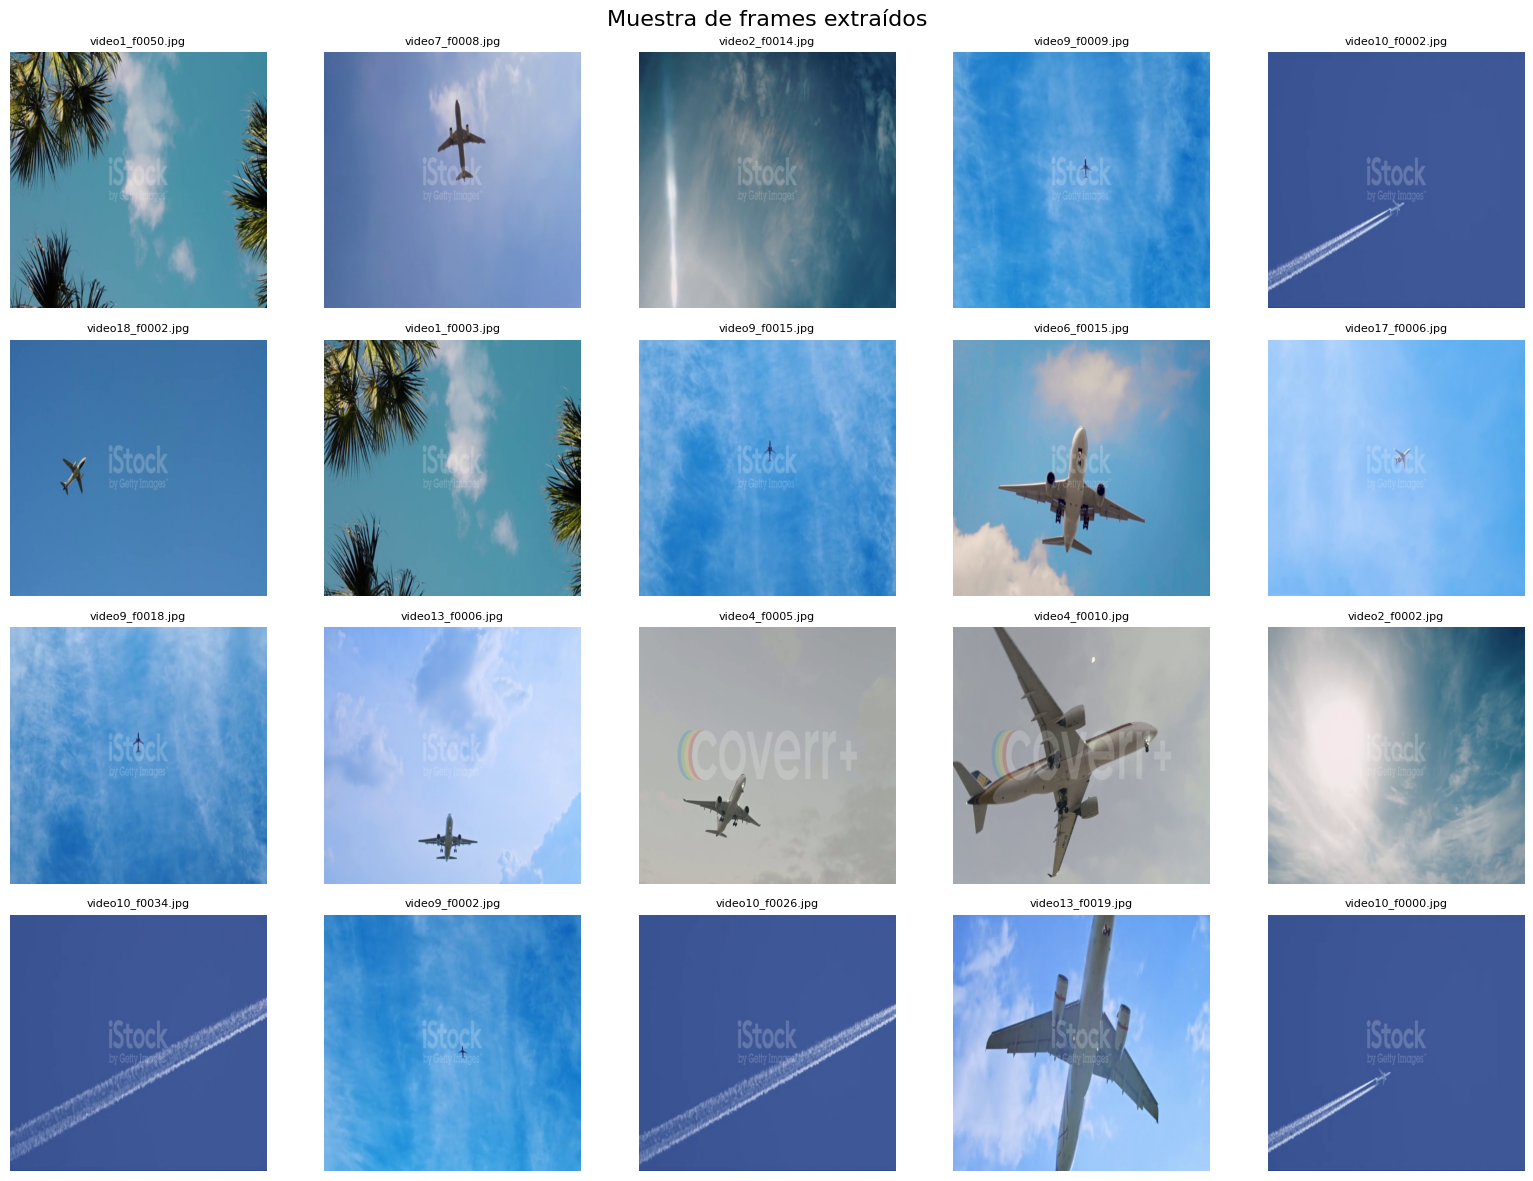

✅ Se mostraron 20 frames de muestra


In [15]:
import glob
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

all_frames = glob.glob('dataset/images/all_frames/*.jpg')
sample_frames = random.sample(all_frames, min(20, len(all_frames)))

fig, axes = plt.subplots(4, 5, figsize=(16, 12))
fig.suptitle('Muestra de frames extraídos', fontsize=16)

for ax, img_path in zip(axes.flat, sample_frames):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'✅ Se mostraron {len(sample_frames)} frames de muestra')

Total de frames disponibles: 566


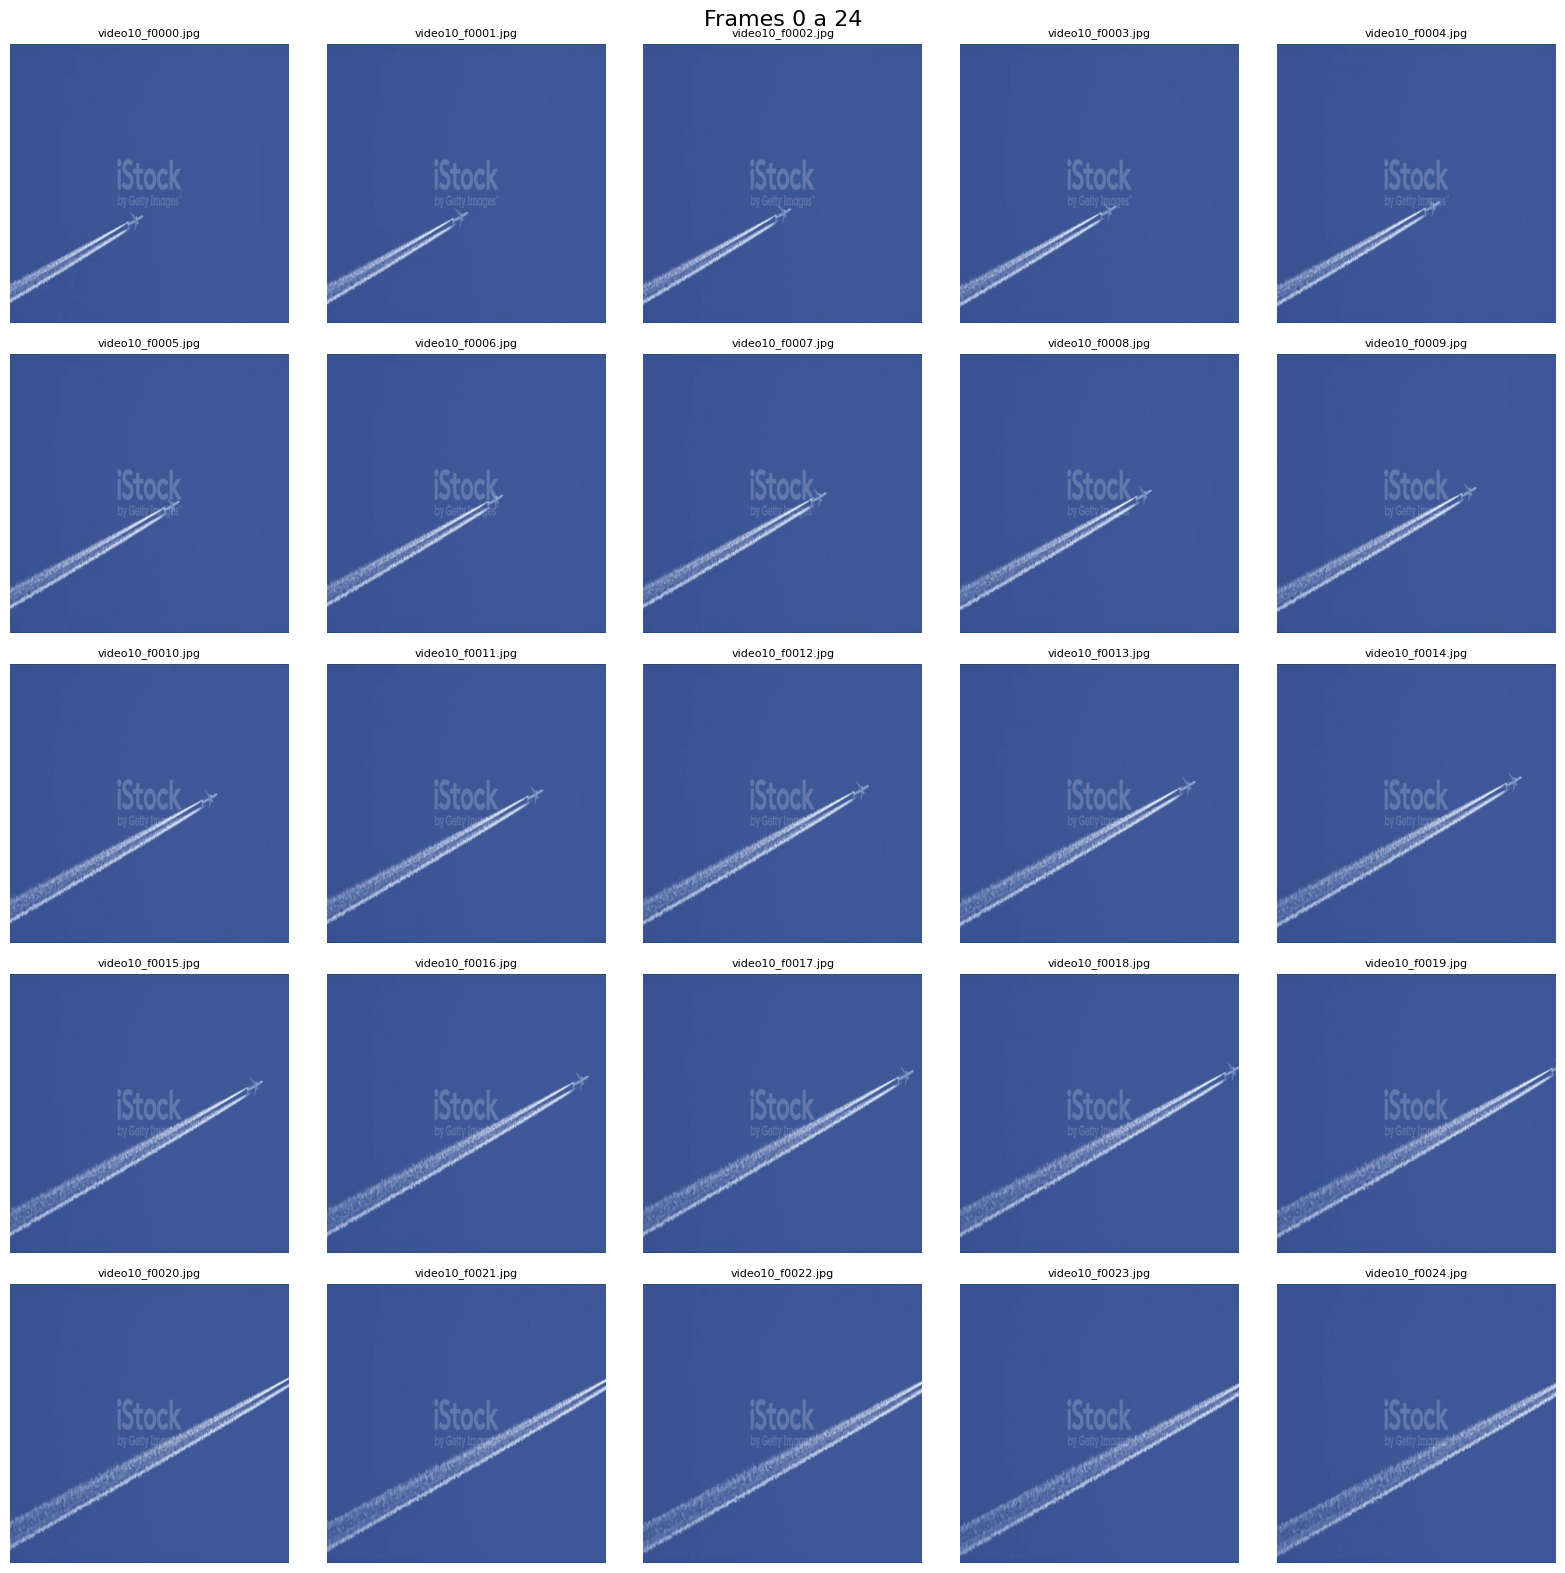

In [16]:
import glob
import os
import math
import random
import matplotlib.pyplot as plt
from PIL import Image

all_frames = sorted(glob.glob('dataset/images/all_frames/*.jpg'))
print(f'Total de frames disponibles: {len(all_frames)}')

# Cambia este número para ver otro lote
batch_size = 25
start_idx = 0   # luego puedes poner 25, 50, 75, etc.

batch = all_frames[start_idx:start_idx + batch_size]

rows, cols = 5, 5
fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
fig.suptitle(f'Frames {start_idx} a {start_idx + len(batch) - 1}', fontsize=16)

for ax, img_path in zip(axes.flat, batch):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(os.path.basename(img_path), fontsize=8)
    ax.axis('off')

# Si sobran ejes vacíos
for ax in axes.flat[len(batch):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [17]:
import os
import glob
import shutil

# Rutas
source_folder = 'dataset/images/all_frames'
selected_folder = 'dataset/images/selected'

# Crear carpeta destino
os.makedirs(selected_folder, exist_ok=True)

# Limpiar selected si ya tenía algo
for f in glob.glob(os.path.join(selected_folder, '*')):
    os.remove(f)

# Buscar imágenes limpias que dejaste en all_frames
images = sorted(
    glob.glob(os.path.join(source_folder, '*.jpg')) +
    glob.glob(os.path.join(source_folder, '*.png')) +
    glob.glob(os.path.join(source_folder, '*.jpeg'))
)

print(f'📸 Imágenes buenas encontradas: {len(images)}')

# Copiar a carpeta final
for img_path in images:
    filename = os.path.basename(img_path)
    shutil.copy2(img_path, os.path.join(selected_folder, filename))

print(f'✅ Imágenes copiadas a: {selected_folder}')
print(f'✅ Total listo para etiquetar: {len(os.listdir(selected_folder))}')

📸 Imágenes buenas encontradas: 473
✅ Imágenes copiadas a: dataset/images/selected
✅ Total listo para etiquetar: 473


In [19]:
import sys
!{sys.executable} -m pip install -U ultralytics

  Using cached ultralytics-8.4.51-py3-none-any.whl.metadata (36 kB)
  Using cached scipy-1.17.1-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Using cached torch-2.12.0-cp311-cp311-win_amd64.whl.metadata (31 kB)
  Using cached torchvision-0.27.0-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached polars-1.40.1-py3-none-any.whl.metadata (10 kB)
  Using cached ultralytics_thop-2.0.19-py3-none-any.whl.metadata (14 kB)
  Using cached polars_runtime_32-1.40.1-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached ultralytics-8.4.51-py3-none-any.whl (1.2 MB)
Using cached polars-1.40.1-py3-none-any.whl (828 kB)
Using cached polars_runtime_32-1.40.1-cp310-abi3-win_amd64.wh


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from ultralytics import YOLO
print("✅ Ultralytics importado correctamente")

✅ Ultralytics importado correctamente


In [21]:
import os
import glob
from ultralytics import YOLO

# Carpetas
image_folder = 'dataset/images/selected'
label_folder = 'dataset/labels/selected'
os.makedirs(label_folder, exist_ok=True)

# Limpiar etiquetas viejas si existen
for f in glob.glob(os.path.join(label_folder, '*.txt')):
    os.remove(f)

# Cargar modelo preentrenado
model = YOLO('yolov8m.pt')  # puede descargar el peso automáticamente la primera vez

# Ejecutar predicción y guardar txt
results = model.predict(
    source=image_folder,
    conf=0.20,          # umbral bajo para no perder aviones
    imgsz=640,
    save=False,
    save_txt=True,
    save_conf=False,
    classes=[4],        # 4 = airplane en COCO
    project='dataset',
    name='auto_labels',
    exist_ok=True,
    verbose=True
)

print("✅ Predicción terminada")
print("Revisa ahora la carpeta: dataset/auto_labels/labels")


image 1/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0000.jpg: 640x640 1 airplane, 330.7ms
image 2/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0001.jpg: 640x640 (no detections), 327.9ms
image 3/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0002.jpg: 640x640 (no detections), 296.2ms
image 4/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0003.jpg: 640x640 (no detections), 298.4ms
image 5/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0004.jpg: 640x640 (no detections), 296.5ms
image 6/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0005.jpg: 640x640 (no detections), 287.1ms
image 7/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0006.jpg: 640x640 (no detections), 290.5ms
image 8/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f0007.jpg: 640x640 (no detections), 289.4ms
image 9/473 C:\Users\User\tarea_aviones\dataset\images\selected\video10_f000

In [22]:
import os
import glob
import shutil

# Carpeta donde Ultralytics guardó las etiquetas
src_labels = 'runs/detect/dataset/auto_labels/labels'

# Carpeta final
dst_labels = 'dataset/labels/selected'
os.makedirs(dst_labels, exist_ok=True)

# Limpiar destino
for f in glob.glob(os.path.join(dst_labels, '*.txt')):
    os.remove(f)

# Copiar etiquetas generadas
label_files = sorted(glob.glob(os.path.join(src_labels, '*.txt')))
print(f'🏷️  Etiquetas encontradas: {len(label_files)}')

copied = 0
for lf in label_files:
    shutil.copy2(lf, os.path.join(dst_labels, os.path.basename(lf)))
    copied += 1

print(f'✅ Etiquetas copiadas: {copied}')
print(f'📁 Carpeta destino: {dst_labels}')

# Verificar cuántas imágenes tienen etiqueta
image_files = sorted(glob.glob('dataset/images/selected/*.jpg'))
print(f'🖼️  Imágenes seleccionadas: {len(image_files)}')

🏷️  Etiquetas encontradas: 410
✅ Etiquetas copiadas: 410
📁 Carpeta destino: dataset/labels/selected
🖼️  Imágenes seleccionadas: 473


In [23]:
import os
import glob
import shutil
import random

# Rutas
img_src = 'dataset/images/selected'
lbl_src = 'dataset/labels/selected'

final_img_train = 'dataset/images/train'
final_img_val = 'dataset/images/val'
final_lbl_train = 'dataset/labels/train'
final_lbl_val = 'dataset/labels/val'

for p in [final_img_train, final_img_val, final_lbl_train, final_lbl_val]:
    os.makedirs(p, exist_ok=True)

# Limpiar destinos
for folder in [final_img_train, final_img_val, final_lbl_train, final_lbl_val]:
    for f in glob.glob(os.path.join(folder, '*')):
        os.remove(f)

# Listar imágenes
images = sorted(glob.glob(os.path.join(img_src, '*.jpg')))
print(f'🖼️ Imágenes totales en selected: {len(images)}')

# Separar imágenes con etiqueta y sin etiqueta
with_label = []
without_label = []

for img_path in images:
    stem = os.path.splitext(os.path.basename(img_path))[0]
    lbl_path = os.path.join(lbl_src, stem + '.txt')
    if os.path.exists(lbl_path):
        with_label.append(img_path)
    else:
        without_label.append(img_path)

print(f'✅ Con etiqueta: {len(with_label)}')
print(f'⚪ Sin etiqueta: {len(without_label)}')

# Decisión:
# - Conservamos todas las etiquetadas
# - Conservamos las sin etiqueta como background, pero en pequeña proporción
#   Si no quieres usarlas, cambia keep_background = False
keep_background = True

final_list = with_label.copy()
if keep_background:
    random.seed(42)
    bg_keep = random.sample(without_label, min(len(without_label), max(10, len(with_label)//10)))
    final_list.extend(bg_keep)
    print(f'🟦 Background conservado: {len(bg_keep)}')
else:
    bg_keep = []
    print('🟥 Background descartado')

random.shuffle(final_list)

# Split 80/20
split_idx = int(len(final_list) * 0.8)
train_imgs = final_list[:split_idx]
val_imgs = final_list[split_idx:]

print(f'\n📊 Train: {len(train_imgs)}')
print(f'📊 Val:   {len(val_imgs)}')

def copy_split(img_list, img_dst, lbl_dst):
    count_lbl = 0
    for img_path in img_list:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        shutil.copy2(img_path, os.path.join(img_dst, os.path.basename(img_path)))
        lbl_path = os.path.join(lbl_src, stem + '.txt')
        if os.path.exists(lbl_path):
            shutil.copy2(lbl_path, os.path.join(lbl_dst, stem + '.txt'))
            count_lbl += 1
    return count_lbl

train_lbls = copy_split(train_imgs, final_img_train, final_lbl_train)
val_lbls = copy_split(val_imgs, final_img_val, final_lbl_val)

print(f'\n✅ Etiquetas copiadas en train: {train_lbls}')
print(f'✅ Etiquetas copiadas en val:   {val_lbls}')
print(f'✅ Dataset listo para entrenamiento')

🖼️ Imágenes totales en selected: 473
✅ Con etiqueta: 410
⚪ Sin etiqueta: 63
🟦 Background conservado: 41

📊 Train: 360
📊 Val:   91

✅ Etiquetas copiadas en train: 328
✅ Etiquetas copiadas en val:   82
✅ Dataset listo para entrenamiento


In [24]:
from pathlib import Path

yaml_text = """path: dataset
train: images/train
val: images/val

nc: 1
names:
  0: airplane
"""

Path('dataset/data.yaml').write_text(yaml_text, encoding='utf-8')
print('✅ data.yaml creado en dataset/data.yaml')
print(yaml_text)

✅ data.yaml creado en dataset/data.yaml
path: dataset
train: images/train
val: images/val

nc: 1
names:
  0: airplane



In [25]:
import glob
import os

for split in ['train', 'val']:
    imgs = sorted(glob.glob(f'dataset/images/{split}/*.jpg'))
    lbls = sorted(glob.glob(f'dataset/labels/{split}/*.txt'))
    
    print(f'\n{split.upper()}')
    print(f'Imágenes: {len(imgs)}')
    print(f'Etiquetas: {len(lbls)}')
    
    missing = []
    for img in imgs:
        stem = os.path.splitext(os.path.basename(img))[0]
        lbl = f'dataset/labels/{split}/{stem}.txt'
        if not os.path.exists(lbl):
            missing.append(stem)
    
    print(f'Sin etiqueta: {len(missing)}')
    if missing[:10]:
        print('Ejemplos:', missing[:10])


TRAIN
Imágenes: 360
Etiquetas: 328
Sin etiqueta: 32
Ejemplos: ['video10_f0001', 'video10_f0002', 'video10_f0003', 'video10_f0005', 'video10_f0006', 'video10_f0007', 'video10_f0008', 'video10_f0009', 'video11_f0001', 'video11_f0003']

VAL
Imágenes: 91
Etiquetas: 82
Sin etiqueta: 9
Ejemplos: ['video12_f0008', 'video12_f0019', 'video5_f0028', 'video5_f0029', 'video5_f0031', 'video5_f0036', 'video6_f0046', 'video9_f0000', 'video9_f0011']


In [26]:
import glob
import os

for split in ['train', 'val']:
    imgs = sorted(glob.glob(f'dataset/images/{split}/*.jpg'))
    lbls = sorted(glob.glob(f'dataset/labels/{split}/*.txt'))
    
    nonempty = 0
    empty = 0
    
    for lbl in lbls:
        if os.path.getsize(lbl) > 0:
            nonempty += 1
        else:
            empty += 1
    
    missing = 0
    for img in imgs:
        stem = os.path.splitext(os.path.basename(img))[0]
        lbl = f'dataset/labels/{split}/{stem}.txt'
        if not os.path.exists(lbl):
            missing += 1
    
    print(f'\n{split.upper()}')
    print(f'Imágenes: {len(imgs)}')
    print(f'Etiquetas: {len(lbls)}')
    print(f'Etiquetas con contenido: {nonempty}')
    print(f'Etiquetas vacías: {empty}')
    print(f'Imágenes sin label: {missing}')


TRAIN
Imágenes: 360
Etiquetas: 328
Etiquetas con contenido: 328
Etiquetas vacías: 0
Imágenes sin label: 32

VAL
Imágenes: 91
Etiquetas: 82
Etiquetas con contenido: 82
Etiquetas vacías: 0
Imágenes sin label: 9


In [27]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    device='cpu',   # cambia a 0 si tienes GPU disponible
    name='airplane_yolov8',
    project='runs/detect',
    patience=15,
    save=True,
    plots=True,
    verbose=True
)

print('✅ Entrenamiento terminado')

Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600GT with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=airplane_yolov8, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50         0G          0      58.76          0          0        640: 100% ━━━━━━━━━━━━ 4/4 2.0s/it 7.8s2.9ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50         0G          0      57.56          0          0        640: 100% ━━━━━━━━━━━━ 4/4 1.8s/it 7.3s2.8ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3it/s 0.8s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50         0G          0      30.62          0          0        640: 100% ━━━━━━━━━━━━ 4/4 1.7s/it 6.6s2.5ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.3it/s 0.7s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



50 epochs completed in 0.107 hours.
Optimizer stripped from C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8\weights\last.pt, 6.2MB
Optimizer stripped from C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8\weights\best.pt, 6.2MB

Validating C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8\weights\best.pt...
Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600GT with Radeon Graphics)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.5it/s 0.7s


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\User\AppData\Local\Program

                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.6ms preprocess, 60.6ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8
✅ Entrenamiento terminado


In [28]:
import glob
import os

for split in ['train', 'val']:
    imgs = sorted(glob.glob(f'dataset/images/{split}/*.jpg'))
    lbls = sorted(glob.glob(f'dataset/labels/{split}/*.txt'))
    print(f'\n{split.upper()}')
    print('imágenes:', len(imgs))
    print('etiquetas:', len(lbls))
    print('primeras imágenes:', [os.path.basename(x) for x in imgs[:5]])
    print('primeras etiquetas:', [os.path.basename(x) for x in lbls[:5]])


TRAIN
imágenes: 360
etiquetas: 328
primeras imágenes: ['video10_f0000.jpg', 'video10_f0001.jpg', 'video10_f0002.jpg', 'video10_f0003.jpg', 'video10_f0005.jpg']
primeras etiquetas: ['video10_f0000.txt', 'video10_f0010.txt', 'video10_f0011.txt', 'video10_f0012.txt', 'video10_f0013.txt']

VAL
imágenes: 91
etiquetas: 82
primeras imágenes: ['video11_f0016.jpg', 'video11_f0022.jpg', 'video12_f0000.jpg', 'video12_f0008.jpg', 'video12_f0014.jpg']
primeras etiquetas: ['video11_f0016.txt', 'video11_f0022.txt', 'video12_f0000.txt', 'video12_f0014.txt', 'video13_f0001.txt']


In [29]:
import glob
import os

cache_files = glob.glob('dataset/**/*.cache', recursive=True)
for f in cache_files:
    os.remove(f)
    print(f'Borrado: {f}')

print(f'Total cache borrados: {len(cache_files)}')

Borrado: dataset\labels\train.cache
Borrado: dataset\labels\val.cache
Total cache borrados: 2


In [30]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

results = model.train(
    data='dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    device='cpu',
    name='airplane_yolov8_clean',
    project='runs/detect',
    patience=15,
    save=True,
    plots=True,
    verbose=True
)

print('✅ Entrenamiento terminado')

Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600GT with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=airplane_yolov8_clean, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50         0G          0      58.76          0          0        640: 100% ━━━━━━━━━━━━ 4/4 1.8s/it 7.1s2.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.2it/s 0.8s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50         0G          0      57.56          0          0        640: 100% ━━━━━━━━━━━━ 4/4 1.8s/it 7.3s2.7ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      50/50         0G          0      30.62          0          0        640: 100% ━━━━━━━━━━━━ 4/4 1.6s/it 6.4s2.4ss
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s
                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels

50 epochs completed in 0.105 hours.


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:839: RuntimeWarning: Mean of empty slice
  i = smooth(f1_curve.mean(0), 0.1).argmax()  # max F1 index
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Optimizer stripped from C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8_clean\weights\last.pt, 6.2MB
Optimizer stripped from C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8_clean\weights\best.pt, 6.2MB

Validating C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8_clean\weights\best.pt...
Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600GT with Radeon Graphics)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.4it/s 0.7s


C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:657: RuntimeWarning: Mean of empty slice
  ax.plot(px, py.mean(1), linewidth=3, color="blue", label=f"all classes {ap[:, 0].mean():.3f} mAP@0.5")
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\_core\_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\ultralytics\utils\metrics.py:703: RuntimeWarning: Mean of empty slice
  y = smooth(py.mean(0), 0.1)
C:\Users\User\AppData\Local\Program

                   all          9          0          0          0          0          0
WARNING no labels found in detect set, cannot compute metrics without labels
Speed: 1.7ms preprocess, 65.8ms inference, 0.0ms loss, 4.0ms postprocess per image
Results saved to C:\Users\User\tarea_aviones\runs\detect\runs\detect\airplane_yolov8_clean
✅ Entrenamiento terminado


In [31]:
from pathlib import Path

for txt in Path('dataset/labels').rglob('*.txt'):
    lines = txt.read_text(encoding='utf-8').strip().splitlines()
    new_lines = []
    for line in lines:
        parts = line.split()
        if len(parts) == 5:
            parts[0] = '0'
            new_lines.append(' '.join(parts))
    txt.write_text('\n'.join(new_lines) + ('\n' if new_lines else ''), encoding='utf-8')

print('✅ Etiquetas corregidas a clase 0')

✅ Etiquetas corregidas a clase 0


In [32]:
import glob, os
for f in glob.glob('dataset/**/*.cache', recursive=True):
    os.remove(f)
print('✅ caches borrados')

✅ caches borrados


In [33]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(
    data='dataset/data.yaml',
    epochs=50,
    imgsz=640,
    batch=8,
    device='cpu',
    name='airplane_yolov8_fixed',
    project='runs/detect',
    patience=15,
    save=True,
    plots=True,
    verbose=True
)

Ultralytics 8.4.51  Python-3.11.9 torch-2.12.0+cpu CPU (AMD Ryzen 5 5600GT with Radeon Graphics)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=airplane_yolov8_fixed, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=Tru

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001FAD845BFD0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0480

In [36]:
!pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB 1.3 MB/s eta 0:00:08
   --- ------------------------------------ 0.9/9.9 MB 13.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.9/9.9 MB 35.4 MB/s eta 0:00:01
   ------------------------------------ --- 9.0/9.9 MB 57.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 52.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
import glob

runs = glob.glob('runs/detect/*')
print('Carpetas encontradas:')
for r in runs:
    print(r)

Carpetas encontradas:
runs/detect\dataset
runs/detect\runs


In [39]:
import glob

best_files = glob.glob('runs/**/best.pt', recursive=True)
last_files = glob.glob('runs/**/last.pt', recursive=True)

print('best.pt encontrados:')
for f in best_files:
    print(f)

print('\nlast.pt encontrados:')
for f in last_files:
    print(f)

best.pt encontrados:
runs\detect\runs\detect\airplane_yolov8\weights\best.pt
runs\detect\runs\detect\airplane_yolov8_clean\weights\best.pt
runs\detect\runs\detect\airplane_yolov8_fixed\weights\best.pt

last.pt encontrados:
runs\detect\runs\detect\airplane_yolov8\weights\last.pt
runs\detect\runs\detect\airplane_yolov8_clean\weights\last.pt
runs\detect\runs\detect\airplane_yolov8_fixed\weights\last.pt


In [40]:
from pathlib import Path
import shutil

src = Path(r"runs/detect/runs/detect/airplane_yolov8_fixed/weights/best.pt")
dst_dir = Path("entrega_final")
dst_dir.mkdir(exist_ok=True)

shutil.copy2(src, dst_dir / "best.pt")
print("✅ Modelo copiado a:", dst_dir / "best.pt")

✅ Modelo copiado a: entrega_final\best.pt


In [41]:
from pathlib import Path
import shutil

final_dir = Path("entrega_final")
final_dir.mkdir(exist_ok=True)

paths_to_copy = [
    Path("dataset/images"),
    Path("dataset/labels"),
    Path("dataset/data.yaml"),
    Path(r"runs/detect/runs/detect/airplane_yolov8_fixed/weights/best.pt"),
]

for p in paths_to_copy:
    dest = final_dir / p.name
    if p.is_dir():
        if dest.exists():
            shutil.rmtree(dest)
        shutil.copytree(p, dest)
    elif p.is_file():
        shutil.copy2(p, dest)

print("✅ Carpeta final lista en:", final_dir.resolve())

✅ Carpeta final lista en: C:\Users\User\tarea_aviones\entrega_final



image 1/1 C:\Users\User\tarea_aviones\imagen_prueba.jpg: 448x640 1 airplane, 43.7ms
Speed: 2.1ms preprocess, 43.7ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)


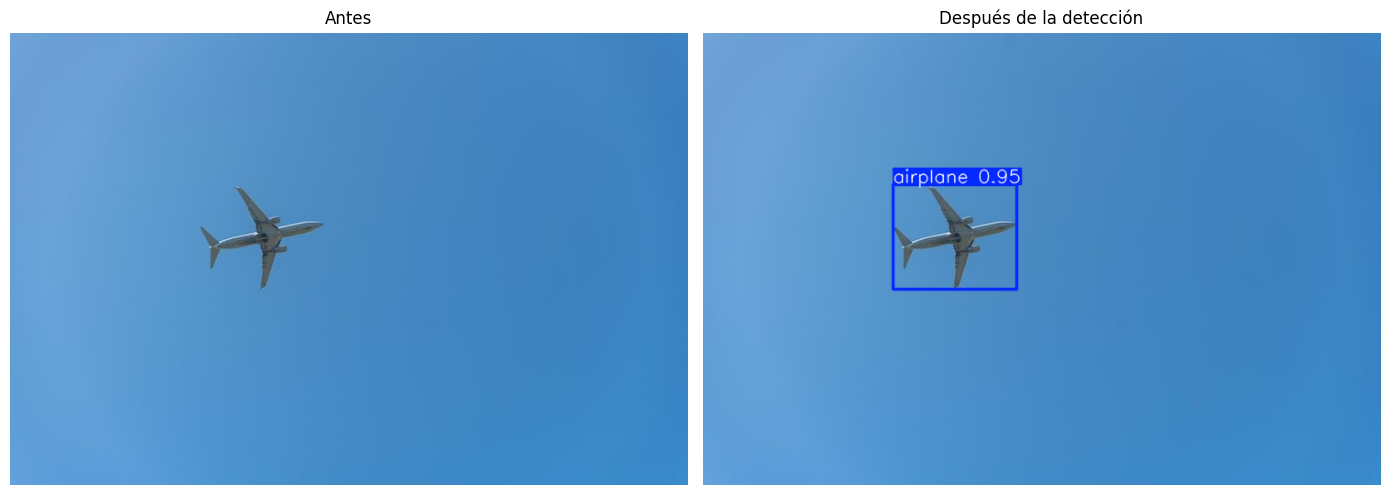

In [46]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

img_path = r"C:\Users\User\tarea_aviones\imagen_prueba.jpg"

model = YOLO(r"runs/detect/runs/detect/airplane_yolov8_fixed/weights/best.pt")
results = model.predict(source=img_path, conf=0.25, save=False)

original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

detected = results[0].plot()
detected = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Antes")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(detected)
plt.title("Después de la detección")
plt.axis("off")

plt.tight_layout()
plt.show()


image 1/1 C:\Users\User\tarea_aviones\imagen_prueba2.jpg: 448x640 1 airplane, 53.5ms
Speed: 3.0ms preprocess, 53.5ms inference, 1.0ms postprocess per image at shape (1, 3, 448, 640)


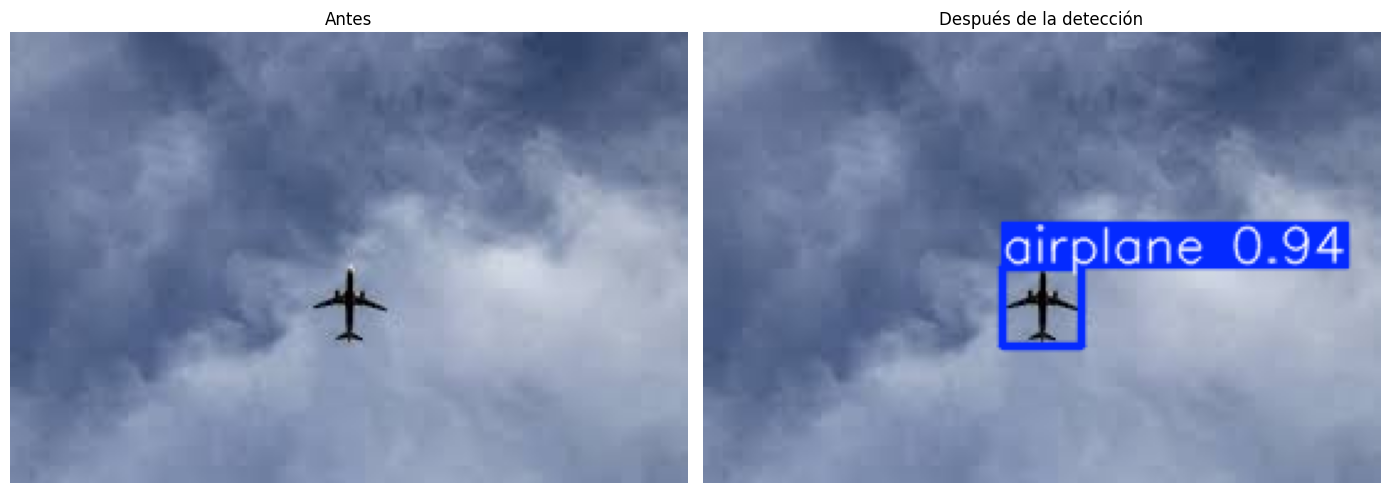

In [47]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

img_path = r"C:\Users\User\tarea_aviones\imagen_prueba2.jpg"

model = YOLO(r"runs/detect/runs/detect/airplane_yolov8_fixed/weights/best.pt")
results = model.predict(source=img_path, conf=0.25, save=False)

original = cv2.imread(img_path)
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

detected = results[0].plot()
detected = cv2.cvtColor(detected, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Antes")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(detected)
plt.title("Después de la detección")
plt.axis("off")

plt.tight_layout()
plt.show()